# Sales Forecasting (LSTM)
- Monthly revenue aggregation
- MinMax scaling
- Sequence creation (sliding window)
- Bidirectional LSTM model (TensorFlow/Keras)
- Train/test evaluation (RMSE, MAE, MAPE)
- Future 6-month forecast
- Save model + forecast CSV 

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import pickle, os, warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

print(f"TensorFlow version: {tf.__version__}")

TensorFlow version: 2.20.0


## 2. Load & Aggregate Monthly Revenue

In [2]:
transactions = pd.read_csv('../data/Transactions.csv')
transactions['transaction_date'] = pd.to_datetime(transactions['transaction_date'])

monthly = (transactions
    .groupby(transactions['transaction_date'].dt.to_period('M'))['total_amount']
    .sum().reset_index())
monthly.columns = ['month', 'revenue']
monthly['month_dt'] = monthly['month'].dt.to_timestamp()
monthly = monthly.sort_values('month_dt').reset_index(drop=True)

print(f"Monthly periods: {len(monthly)}")
print(f"Date range: {monthly['month_dt'].min().date()} → {monthly['month_dt'].max().date()}")
print(f"Revenue range: ₹{monthly['revenue'].min():,.0f} → ₹{monthly['revenue'].max():,.0f}")
monthly.tail()

Monthly periods: 36
Date range: 2023-01-01 → 2025-12-01
Revenue range: ₹52,786,498 → ₹78,201,507


,month,revenue,month_dt
31,2025-08,62812993.29,2025-08-01
32,2025-09,67588706.07,2025-09-01
33,2025-10,69498070.74,2025-10-01
34,2025-11,74442166.97,2025-11-01
35,2025-12,59548288.23,2025-12-01


## 3. Visualise Raw Monthly Revenue

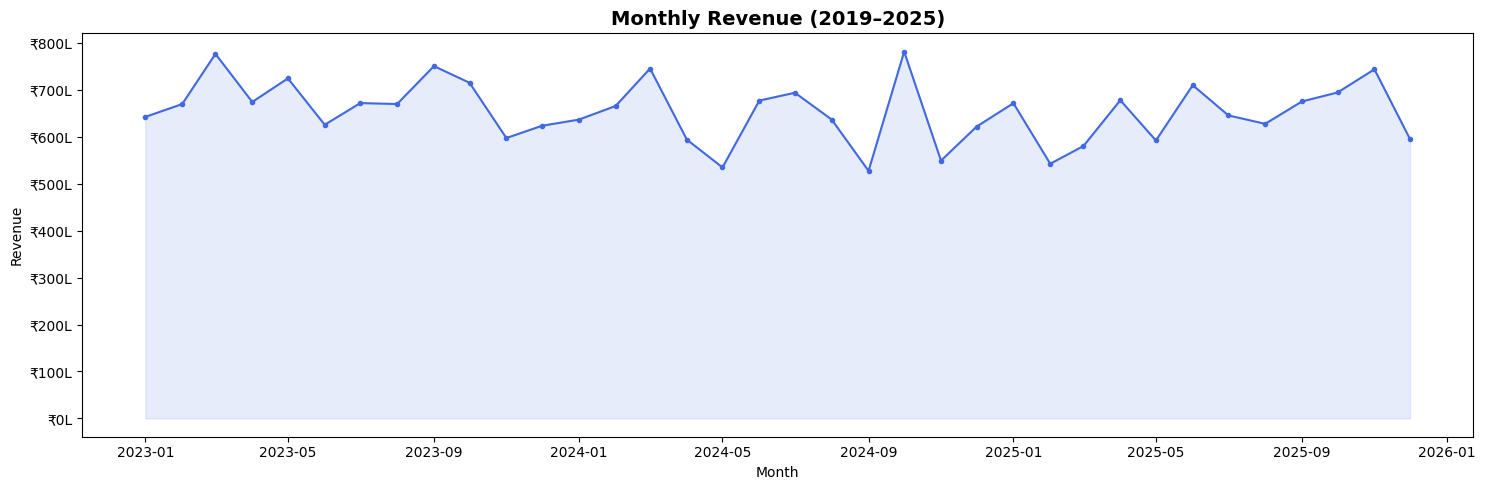

In [3]:
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(monthly['month_dt'], monthly['revenue'], color='royalblue', linewidth=1.5, marker='o', markersize=3)
ax.fill_between(monthly['month_dt'], monthly['revenue'], alpha=0.12, color='royalblue')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'₹{x/1e5:.0f}L'))
ax.set_title('Monthly Revenue (2019–2025)', fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Revenue')
plt.tight_layout()
plt.savefig('../output/lstm_raw_revenue.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Scale & Create LSTM Sequences

In [4]:
scaler_lstm = MinMaxScaler(feature_range=(0, 1))
revenue_scaled = scaler_lstm.fit_transform(monthly[['revenue']])

LOOK_BACK = 12  # Use 12 months to predict next month

def create_sequences(data, look_back):
    X, y = [], []
    for i in range(look_back, len(data)):
        X.append(data[i - look_back:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

X_seq, y_seq = create_sequences(revenue_scaled, LOOK_BACK)
X_seq = X_seq.reshape((X_seq.shape[0], X_seq.shape[1], 1))

split = int(len(X_seq) * 0.8)
X_train, X_test = X_seq[:split], X_seq[split:]
y_train, y_test = y_seq[:split], y_seq[split:]

print(f"X_train: {X_train.shape}  y_train: {y_train.shape}")
print(f"X_test : {X_test.shape}   y_test : {y_test.shape}")

X_train: (19, 12, 1)  y_train: (19,)
X_test : (5, 12, 1)   y_test : (5,)


## 5. Build & Train LSTM Model

In [5]:
model = Sequential([
    Bidirectional(LSTM(64, return_sequences=True), input_shape=(LOOK_BACK, 1)),
    Dropout(0.2),
    LSTM(32, return_sequences=False),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)
])

model.compile(optimizer='adam', loss='huber', metrics=['mae'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 12, 128)        │        33,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 12, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        20,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 54,945 (214.63 KB)

 Trainable params: 54,945 (214.63 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
checkpoint = ModelCheckpoint('../models/lstm_best.keras', save_best_only=True, monitor='val_loss')

history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=8,
    validation_split=0.15,
    callbacks=[early_stop, checkpoint],
    verbose=1
)
print(f"Training stopped at epoch {len(history.history['loss'])}")

Epoch 1/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 502ms/step - loss: 0.1136 - mae: 0.3856 - val_loss: 0.1037 - val_mae: 0.4141
Epoch 2/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step - loss: 0.0941 - mae: 0.3480 - val_loss: 0.0828 - val_mae: 0.3598
Epoch 3/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - loss: 0.0777 - mae: 0.3251 - val_loss: 0.0631 - val_mae: 0.3001
Epoch 4/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - loss: 0.0641 - mae: 0.2929 - val_loss: 0.0431 - val_mae: 0.2240
Epoch 5/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - loss: 0.0557 - mae: 0.2819 - val_loss: 0.0280 - val_mae: 0.1941
Epoch 6/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - loss: 0.0486 - mae: 0.2554 - val_loss: 0.0202 - val_mae: 0.1684
Epoch 7/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step - loss: 0.0512 - mae: 0.2651 - val_loss: 0.0183 - val_mae: 0.1548
Epoch 8/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - loss: 0.0361 - mae: 0.2250 - val_loss: 0.0182 - val_mae: 0.1554
Epoch 9/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - loss: 0.0455

## 6. Training Curves

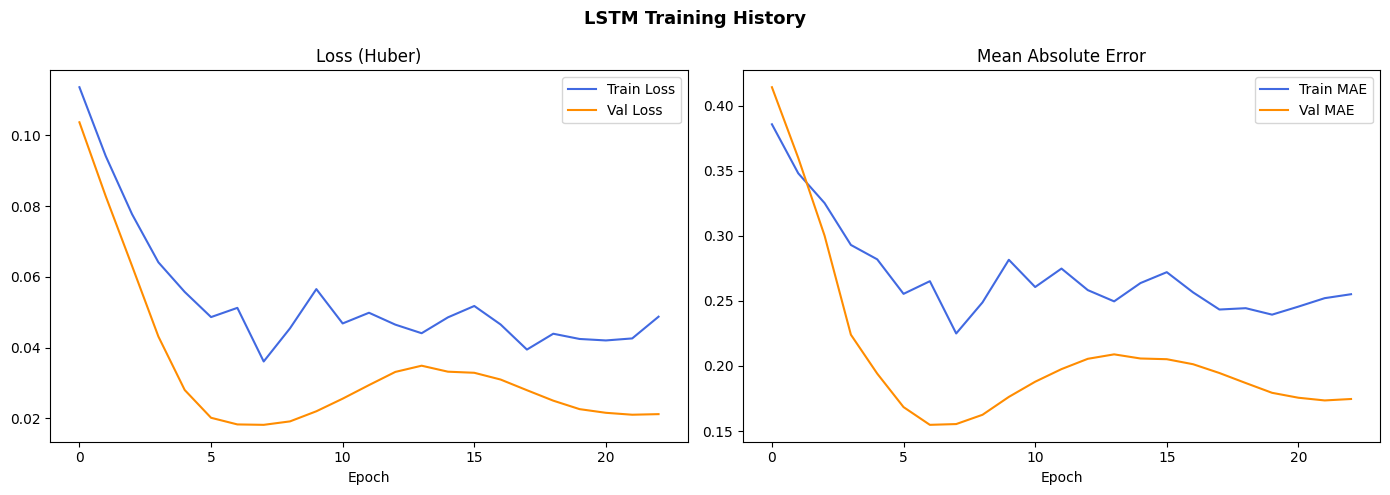

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('LSTM Training History', fontsize=13, fontweight='bold')

axes[0].plot(history.history['loss'], label='Train Loss', color='royalblue')
axes[0].plot(history.history['val_loss'], label='Val Loss', color='darkorange')
axes[0].set_title('Loss (Huber)')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history.history['mae'], label='Train MAE', color='royalblue')
axes[1].plot(history.history['val_mae'], label='Val MAE', color='darkorange')
axes[1].set_title('Mean Absolute Error')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.savefig('../output/lstm_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Evaluate on Test Set

In [8]:
best_model = load_model('../models/lstm_best.keras')

y_pred_train = best_model.predict(X_train)
y_pred_test  = best_model.predict(X_test)

# Inverse transform
y_train_inv = scaler_lstm.inverse_transform(y_train.reshape(-1,1)).flatten()
y_test_inv  = scaler_lstm.inverse_transform(y_test.reshape(-1,1)).flatten()
y_pred_train_inv = scaler_lstm.inverse_transform(y_pred_train).flatten()
y_pred_test_inv  = scaler_lstm.inverse_transform(y_pred_test).flatten()

rmse = np.sqrt(mean_squared_error(y_test_inv, y_pred_test_inv))
mae  = mean_absolute_error(y_test_inv, y_pred_test_inv)
mape = np.mean(np.abs((y_test_inv - y_pred_test_inv) / (y_test_inv + 1e-9))) * 100

print("Test Set Metrics")
print(f"  RMSE : ₹{rmse:,.0f}")
print(f"  MAE  : ₹{mae:,.0f}")
print(f"  MAPE : {mape:.2f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 269ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 285ms/step
Test Set Metrics
  RMSE : ₹5,636,415
  MAE  : ₹4,968,984
  MAPE : 7.39%


## 8. Forecast vs Actual Plot

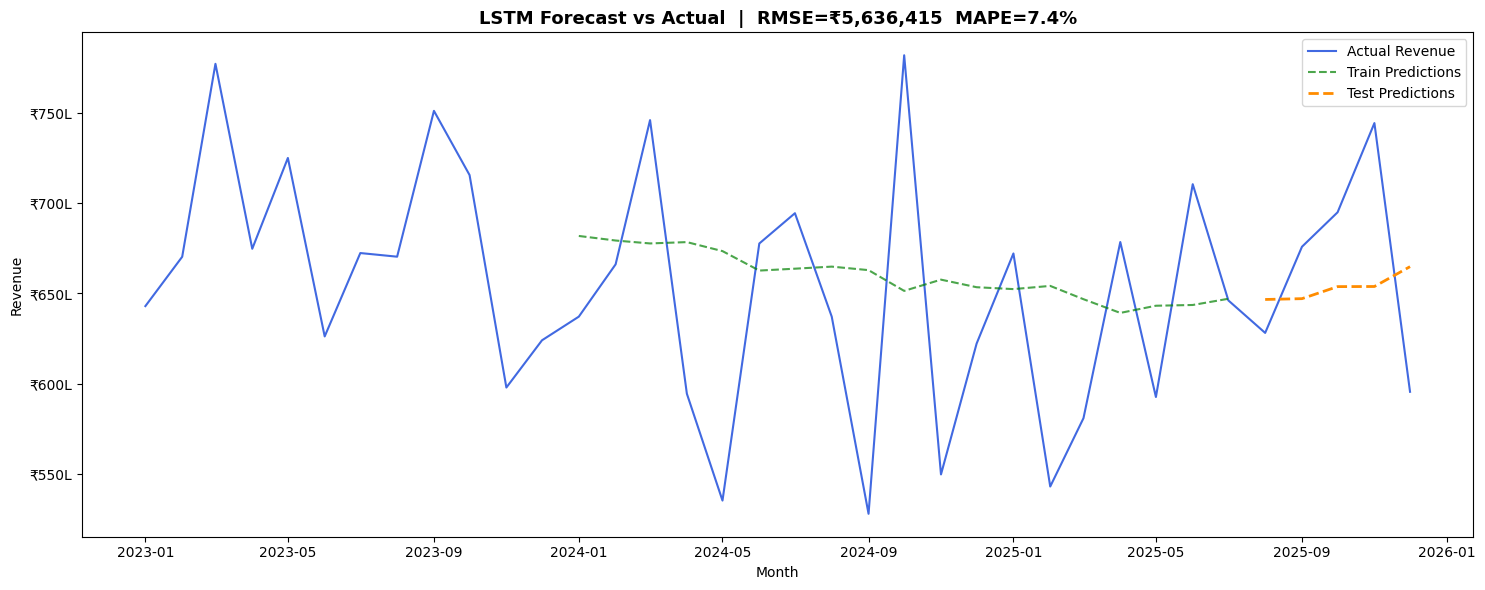

In [9]:
train_dates = monthly['month_dt'].iloc[LOOK_BACK : LOOK_BACK + len(y_train)]
test_dates  = monthly['month_dt'].iloc[LOOK_BACK + len(y_train):]

fig, ax = plt.subplots(figsize=(15, 6))
ax.plot(monthly['month_dt'], monthly['revenue'], color='royalblue',
        linewidth=1.5, label='Actual Revenue')
ax.plot(train_dates, y_pred_train_inv, color='green',
        linewidth=1.5, linestyle='--', label='Train Predictions', alpha=0.7)
ax.plot(test_dates, y_pred_test_inv, color='darkorange',
        linewidth=2, linestyle='--', label='Test Predictions')

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'₹{x/1e5:.0f}L'))
ax.set_title(f'LSTM Forecast vs Actual  |  RMSE=₹{rmse:,.0f}  MAPE={mape:.1f}%',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Revenue')
ax.legend()
plt.tight_layout()
plt.savefig('../output/lstm_forecast_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Future 6-Month Forecast

In [10]:
FORECAST_MONTHS = 6
last_sequence = revenue_scaled[-LOOK_BACK:].copy()
future_preds = []

for _ in range(FORECAST_MONTHS):
    seq = last_sequence[-LOOK_BACK:].reshape(1, LOOK_BACK, 1)
    pred = best_model.predict(seq, verbose=0)[0, 0]
    future_preds.append(pred)
    last_sequence = np.append(last_sequence, [[pred]], axis=0)

future_preds_inv = scaler_lstm.inverse_transform(
    np.array(future_preds).reshape(-1, 1)).flatten()

last_date = monthly['month_dt'].max()
future_dates = pd.date_range(start=last_date + pd.offsets.MonthBegin(1),
                              periods=FORECAST_MONTHS, freq='MS')

forecast_df = pd.DataFrame({'date': future_dates, 'forecast_revenue': future_preds_inv})
forecast_df['date'] = forecast_df['date'].dt.strftime('%Y-%m-%d')
print("6-Month Forecast:")
print(forecast_df.to_string(index=False))

6-Month Forecast:
      date  forecast_revenue
2026-01-01        66368268.0
2026-02-01        66467756.0
2026-03-01        66933780.0
2026-04-01        67252016.0
2026-05-01        67272176.0
2026-06-01        67544608.0


## 10. Forecast Visualisation

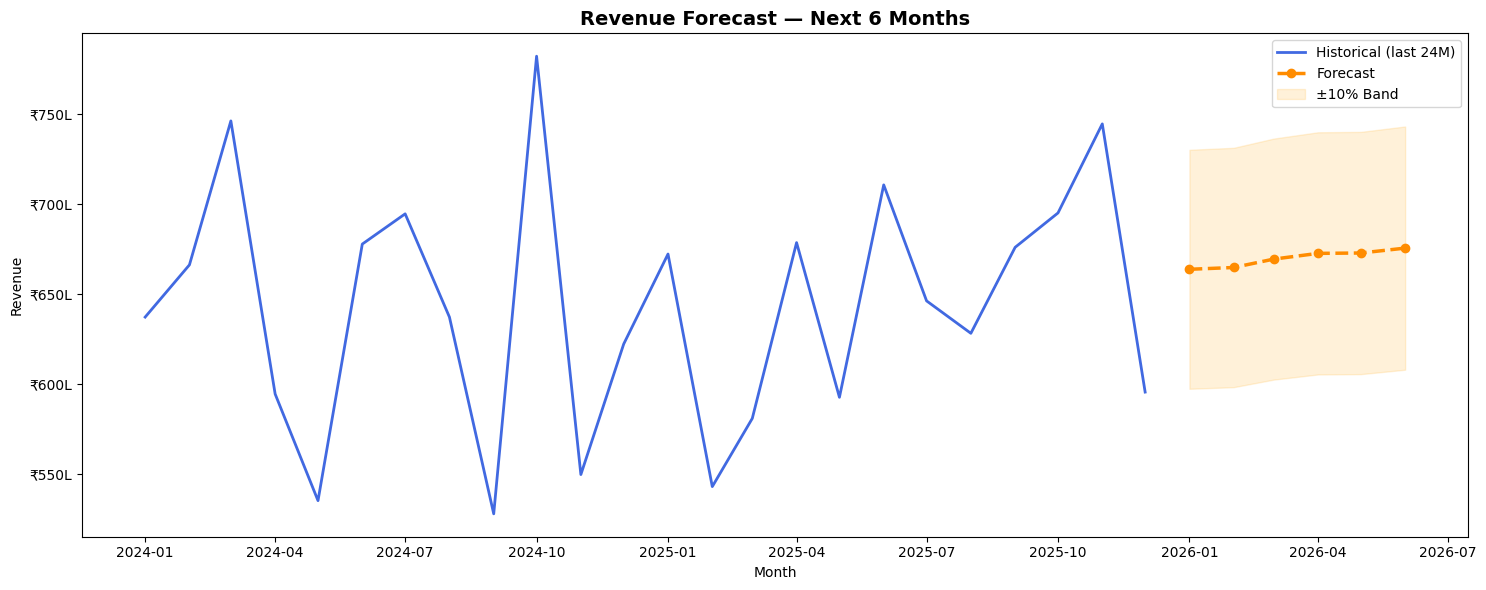

In [11]:
forecast_df_plot = forecast_df.copy()
forecast_df_plot['date'] = pd.to_datetime(forecast_df_plot['date'])

fig, ax = plt.subplots(figsize=(15, 6))
ax.plot(monthly['month_dt'].tail(24), monthly['revenue'].tail(24),
        color='royalblue', linewidth=2, label='Historical (last 24M)')
ax.plot(forecast_df_plot['date'], forecast_df_plot['forecast_revenue'],
        color='darkorange', linewidth=2.5, marker='o', linestyle='--', label='Forecast')
ax.fill_between(forecast_df_plot['date'],
                forecast_df_plot['forecast_revenue'] * 0.90,
                forecast_df_plot['forecast_revenue'] * 1.10,
                color='orange', alpha=0.15, label='±10% Band')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'₹{x/1e5:.0f}L'))
ax.set_title('Revenue Forecast — Next 6 Months', fontsize=14, fontweight='bold')
ax.legend()
ax.set_xlabel('Month')
ax.set_ylabel('Revenue')
plt.tight_layout()
plt.savefig('../output/lstm_future_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Save Artifacts

In [12]:
with open('../models/scaler_lstm.pkl', 'wb') as f:
    pickle.dump(scaler_lstm, f)

forecast_df.to_csv('../output/sales_forecast_output.csv', index=False)
best_model.save('../models/lstm_sales_model.keras')

print("Saved:")
print("   models/lstm_best.keras")
print("   models/lstm_sales_model.keras")
print("   models/scaler_lstm.pkl")
print("   output/sales_forecast_output.csv")

Saved:
   models/lstm_best.keras
   models/lstm_sales_model.keras
   models/scaler_lstm.pkl
   output/sales_forecast_output.csv
